In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("D:\\Projekte\\S.M.A.R.T.-Sovereign_Mail_Assessment_and_Rating_Tool\\scanner\\database\\domainlist.db")

df = pd.read_sql_query("SELECT * FROM osm_names", conn)

df

,id,osm_type,name,federal_state,website,contact_website,contact_email,wikipedia,wikidata,profil,extracted_at
0,94190766,node,Rathaus,Baden-Wuerttemberg,NaN,NaN,NaN,NaN,Q115557395,rathaus,2026-04-16 14:32:35
1,132846993,node,Stadtverwaltung Korntal-Münchingen,Baden-Wuerttemberg,NaN,https://www.korntal-muenchingen.de,NaN,NaN,NaN,rathaus,2026-04-16 14:32:35
2,137982924,node,Rathaus,Baden-Wuerttemberg,"https://www.heidelberg.de/hd,Lde/HD/Rathaus.html",NaN,NaN,de:Rathaus (Heidelberg),Q660785,rathaus,2026-04-16 14:32:35
3,247470380,node,Rathaus Weilheim,Baden-Wuerttemberg,NaN,NaN,NaN,NaN,Q138764098,rathaus,2026-04-16 14:32:35
4,250211735,node,Rathaus,Baden-Wuerttemberg,https://www.korb.de/de/politik-verwaltung/rathaus,NaN,NaN,NaN,NaN,rathaus,2026-04-16 14:32:35
...,...,...,...,...,...,...,...,...,...,...,...
3735,259559998,way,Amtsgericht,Thueringen,NaN,http://www.thueringen.de/th4/olg/gerichte_in_t...,NaN,NaN,NaN,gericht,2026-04-16 14:58:04
3736,463494296,way,Amtsgericht Hildburghausen,Thueringen,https://gerichte.thueringen.de/gerichte-in-thu...,NaN,NaN,NaN,NaN,gericht,2026-04-16 14:58:04
3737,463494297,way,Amtsgericht Hildburghausen,Thueringen,https://gerichte.thueringen.de/gerichte-in-thu...,NaN,NaN,NaN,NaN,gericht,2026-04-16 14:58:04
3738,622818178,way,Landgericht Mühlhausen,Thueringen,NaN,NaN,NaN,NaN,Q1523562,gericht,2026-04-16 14:58:04


In [2]:
cleaned_df = df[(df["website"].notna())][["name", "website", "federal_state", "profil"]]
cleaned_df

,name,website,federal_state,profil
2,Rathaus,"https://www.heidelberg.de/hd,Lde/HD/Rathaus.html",Baden-Wuerttemberg,rathaus
4,Rathaus,https://www.korb.de/de/politik-verwaltung/rathaus,Baden-Wuerttemberg,rathaus
5,Rathaus Staig,http://www.staig.de,Baden-Wuerttemberg,rathaus
7,Ortsverwaltung Haueneberstein,https://www.baden-baden.de/de/buergerservice/c...,Baden-Wuerttemberg,rathaus
8,Rathaus Wannweil,https://wannweil.de/,Baden-Wuerttemberg,rathaus
...,...,...,...,...
3730,Landgericht Erfurt,https://www.thueringen.de/th4/olg/gerichte_in_...,Thueringen,gericht
3731,Amtsgericht Sondershausen,https://www.thueringen.de/de/olg/gerichte_in_t...,Thueringen,gericht
3733,Amtsgericht Rudolstadt,https://www.thueringen.de/th4/olg/gerichte_in_...,Thueringen,gericht
3736,Amtsgericht Hildburghausen,https://gerichte.thueringen.de/gerichte-in-thu...,Thueringen,gericht


In [3]:
import tldextract

def extract_root_domain(url):
    ext = tldextract.extract(url)
    return f"{ext.domain}.{ext.suffix}"

cleaned_df["root_domain"] = cleaned_df["website"].apply(extract_root_domain)
cleaned_df

,name,website,federal_state,profil,root_domain
2,Rathaus,"https://www.heidelberg.de/hd,Lde/HD/Rathaus.html",Baden-Wuerttemberg,rathaus,heidelberg.de
4,Rathaus,https://www.korb.de/de/politik-verwaltung/rathaus,Baden-Wuerttemberg,rathaus,korb.de
5,Rathaus Staig,http://www.staig.de,Baden-Wuerttemberg,rathaus,staig.de
7,Ortsverwaltung Haueneberstein,https://www.baden-baden.de/de/buergerservice/c...,Baden-Wuerttemberg,rathaus,baden-baden.de
8,Rathaus Wannweil,https://wannweil.de/,Baden-Wuerttemberg,rathaus,wannweil.de
...,...,...,...,...,...
3730,Landgericht Erfurt,https://www.thueringen.de/th4/olg/gerichte_in_...,Thueringen,gericht,thueringen.de
3731,Amtsgericht Sondershausen,https://www.thueringen.de/de/olg/gerichte_in_t...,Thueringen,gericht,thueringen.de
3733,Amtsgericht Rudolstadt,https://www.thueringen.de/th4/olg/gerichte_in_...,Thueringen,gericht,thueringen.de
3736,Amtsgericht Hildburghausen,https://gerichte.thueringen.de/gerichte-in-thu...,Thueringen,gericht,thueringen.de


In [ ]:
sample =  cleaned_df.sample(n=10)

for index, row in sample.iterrows():

In [7]:
import asyncio
import pandas as pd
import dns.asyncresolver
from ipwhois import IPWhois
import socket

# -----------------------------
# DNS Resolver (async)
# -----------------------------
resolver = dns.asyncresolver.Resolver()

# Limit concurrency (VERY important)
sem = asyncio.Semaphore(20)

# -----------------------------
# Extract domain (optional helper)
# -----------------------------
def extract_domain(url: str) -> str:
    return url.lower().replace("https://", "").replace("http://", "").split("/")[0]

# -----------------------------
# MX Records
# -----------------------------
async def get_mx(domain):
    try:
        answers = await resolver.resolve(domain, "MX")
        return [str(r.exchange).rstrip(".") for r in answers]
    except:
        return []

# -----------------------------
# A Records (IP resolution for host)
# -----------------------------
async def resolve_ips(host):
    try:
        loop = asyncio.get_running_loop()
        addrinfo = await loop.getaddrinfo(host, None)
        return list({info[4][0] for info in addrinfo})
    except:
        return []

# -----------------------------
# ASN lookup (blocking -> thread)
# -----------------------------
async def get_asn_info(ip):
    def _lookup():
        try:
            obj = IPWhois(ip)
            res = obj.lookup_rdap()
            return {
                "asn": res.get("asn"),
                "asn_org": res.get("asn_description"),
                "network": res.get("network", {}).get("name"),
            }
        except:
            return None

    return await asyncio.to_thread(_lookup)

# -----------------------------
# SMTP banner (optional, blocking)
# -----------------------------
async def get_smtp_banner(host):
    def _banner():
        try:
            with socket.create_connection((host, 25), timeout=5) as s:
                return s.recv(1024).decode(errors="ignore")
        except:
            return None

    return await asyncio.to_thread(_banner)

# -----------------------------
# Process ONE domain
# -----------------------------
async def process_domain(domain):
    async with sem:

        mx_records = await get_mx(domain)

        # Resolve IPs for MX hosts
        ip_lists = await asyncio.gather(
            *[resolve_ips(mx) for mx in mx_records]
        )

        ips = list({ip for sub in ip_lists for ip in sub})

        # ASN lookup
        asn_data = await asyncio.gather(
            *[get_asn_info(ip) for ip in ips]
        )

        # SMTP banner (optional)
        smtp_data = await asyncio.gather(
            *[get_smtp_banner(mx) for mx in mx_records]
        )

        return {
            "domain": domain,
            "mx_records": mx_records,
            "ips": ips,
            "asn": asn_data,
            "smtp_banner": smtp_data
        }

# -----------------------------
# Process DataFrame row
# -----------------------------
async def process_row(row):
    result = await process_domain(row["website"])

    return {
        "name": row["name"],
        "website": row["website"],
        **result
    }

# -----------------------------
# MAIN PIPELINE
# -----------------------------
async def run_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    tasks = [process_row(row) for row in df.to_dict("records")]
    results = await asyncio.gather(*tasks)
    return pd.DataFrame(results)

result_df = asyncio.run(run_pipeline(df))

result_df

RuntimeError: asyncio.run() cannot be called from a running event loop

In [20]:
import pandas as pd
import ast

df = pd.read_csv("D:\Projekte\S.M.A.R.T.-Sovereign_Mail_Assessment_and_Rating_Tool\scanner\enriched_domains.csv")


df["asn"] = df["asn"].apply(ast.literal_eval)

result = []

for _, row in df.iterrows():
    try:
        x = row["asn"]

        if not isinstance(x, list):
            continue

        orgs = {
            i["asn_org"]
            for i in x
            if isinstance(i, dict) and "asn_org" in i
        }

        result.append(list(orgs))

    except Exception:
        # komplett kaputte Zeile skippen
        continue

df["asn_org_unique"] = result

df

<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\P'
C:\Users\jujud\AppData\Local\Temp\ipykernel_17496\2331130100.py:4: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv("D:\Projekte\S.M.A.R.T.-Sovereign_Mail_Assessment_and_Rating_Tool\scanner\enriched_domains.csv")


,name,website,root_domain,federal_state,profil,domain,mx_records,ips,asn,smtp_banner,asn_org_unique
0,Rathaus,"https://www.heidelberg.de/hd,Lde/HD/Rathaus.html",heidelberg.de,Baden-Wuerttemberg,rathaus,heidelberg.de,"['mx7.kvnbw.de', 'mx8.kvnbw.de', 'mx9.kvnbw.de...","['194.0.94.48', '194.59.36.34', '194.59.36.35'...","[{'asn': '50964', 'asn_org': 'KOMM-ONE-AS, DE'...","['220 mx7.kvnbw.de ESMTP Postfix\r\n', '220 mx...","[KOMM-ONE-AS, DE]"
1,Rathaus,https://www.korb.de/de/politik-verwaltung/rathaus,korb.de,Baden-Wuerttemberg,rathaus,korb.de,"['mx9.kvnbw.de', 'mx7.kvnbw.de', 'mx8.kvnbw.de...","['194.0.94.48', '194.59.36.34', '194.59.36.35'...","[{'asn': '50964', 'asn_org': 'KOMM-ONE-AS, DE'...","['220 mx9.kvnbw.de ESMTP Postfix\r\n', '220 mx...","[KOMM-ONE-AS, DE]"
2,Rathaus Staig,http://www.staig.de,staig.de,Baden-Wuerttemberg,rathaus,staig.de,"['mx9.kvnbw.de', 'mx6.kvnbw.de', 'mx8.kvnbw.de...","['194.0.94.48', '194.59.36.34', '194.59.36.35'...","[{'asn': '50964', 'asn_org': 'KOMM-ONE-AS, DE'...","['220 mx9.kvnbw.de ESMTP Postfix\r\n', '220 mx...","[KOMM-ONE-AS, DE]"
3,Ortsverwaltung Haueneberstein,https://www.baden-baden.de/de/buergerservice/c...,baden-baden.de,Baden-Wuerttemberg,rathaus,baden-baden.de,"['mx6.kvnbw.de', 'mx9.kvnbw.de', 'mx7.kvnbw.de...","['194.0.94.48', '194.59.36.34', '194.59.36.35'...","[{'asn': '50964', 'asn_org': 'KOMM-ONE-AS, DE'...","['220 mx6.kvnbw.de ESMTP Postfix\r\n', '220 mx...","[KOMM-ONE-AS, DE]"
4,Rathaus Wannweil,https://wannweil.de/,wannweil.de,Baden-Wuerttemberg,rathaus,wannweil.de,"['mx00.ionos.de', 'mx01.ionos.de']","['217.72.192.67', '212.227.15.41']","[{'asn': '8560', 'asn_org': 'IONOS-AS This is ...",['554-kundenserver.de (mxeue002) Nemesis ESMTP...,"[IONOS-AS This is the joint network for IONOS,..."
...,...,...,...,...,...,...,...,...,...,...,...
2154,Landgericht Erfurt,https://www.thueringen.de/th4/olg/gerichte_in_...,thueringen.de,Thueringen,gericht,thueringen.de,['thmail01.thueringen.de'],['195.191.15.232'],"[{'asn': '196870', 'asn_org': 'FSTH-ASN, DE', ...","['220 thmail04.thueringen.de ESMTP Mon, 20 Apr...","[FSTH-ASN, DE]"
2155,Amtsgericht Sondershausen,https://www.thueringen.de/de/olg/gerichte_in_t...,thueringen.de,Thueringen,gericht,thueringen.de,['thmail01.thueringen.de'],['195.191.15.232'],"[{'asn': '196870', 'asn_org': 'FSTH-ASN, DE', ...","['220 thmail04.thueringen.de ESMTP Mon, 20 Apr...","[FSTH-ASN, DE]"
2156,Amtsgericht Rudolstadt,https://www.thueringen.de/th4/olg/gerichte_in_...,thueringen.de,Thueringen,gericht,thueringen.de,['thmail01.thueringen.de'],['195.191.15.232'],"[{'asn': '196870', 'asn_org': 'FSTH-ASN, DE', ...","['220 thmail04.thueringen.de ESMTP Mon, 20 Apr...","[FSTH-ASN, DE]"
2157,Amtsgericht Hildburghausen,https://gerichte.thueringen.de/gerichte-in-thu...,thueringen.de,Thueringen,gericht,thueringen.de,['thmail01.thueringen.de'],['195.191.15.232'],"[{'asn': '196870', 'asn_org': 'FSTH-ASN, DE', ...","['220 thmail04.thueringen.de ESMTP Mon, 20 Apr...","[FSTH-ASN, DE]"


C:\Users\jujud\AppData\Local\Temp\ipykernel_17496\43629702.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


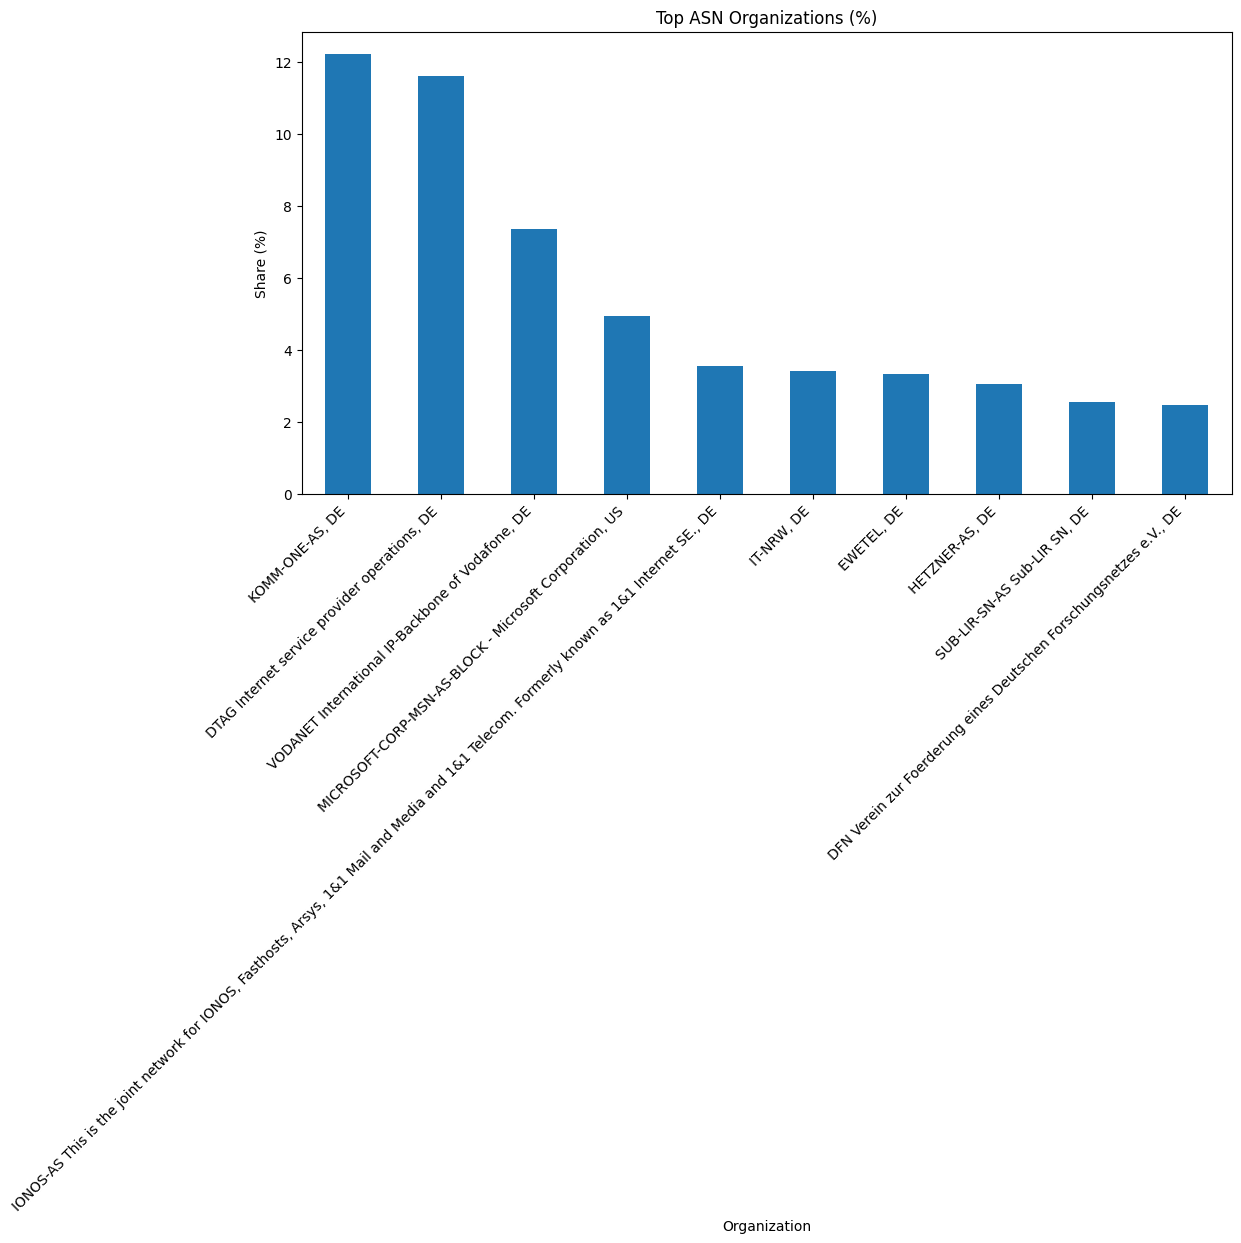

In [22]:
import matplotlib.pyplot as plt

all_orgs = df["asn_org_unique"].explode()
counts = all_orgs.value_counts()
percent = counts / counts.sum() * 100

plt.figure(figsize=(12, 6))

percent.head(10).plot(kind="bar")

plt.title("Top ASN Organizations (%)")
plt.xlabel("Organization")
plt.ylabel("Share (%)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

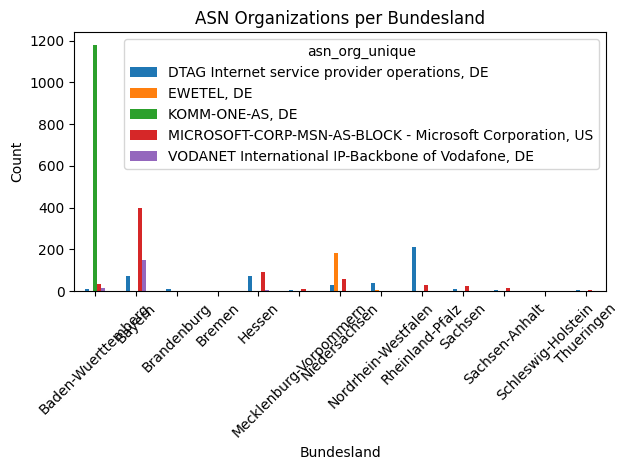

<Figure size 1200x600 with 0 Axes>

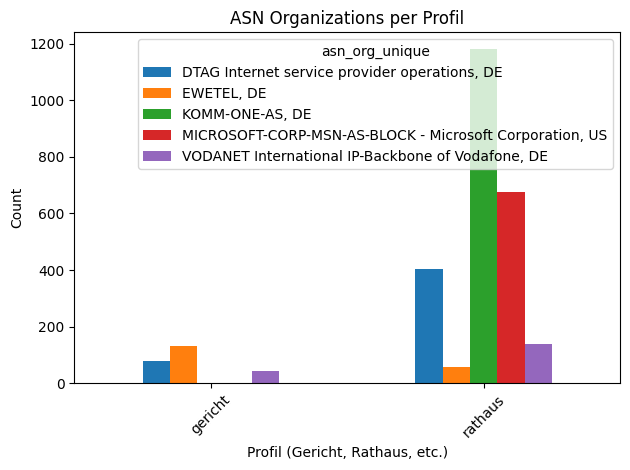

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. CLEAN ASN DATA (robust)
# -----------------------------
def clean_asn_list(x):
    if not isinstance(x, list):
        return []

    cleaned = []
    for i in x:
        if isinstance(i, dict) and "asn_org" in i:
            cleaned.append(i["asn_org"])
    return cleaned


df["asn_org_unique"] = df["asn"].apply(clean_asn_list)

# -----------------------------
# 2. EXPLODE FOR ANALYSIS
# -----------------------------
df_expanded = df.explode("asn_org_unique")

# -----------------------------
# 3. TOP ASN ORGS FILTER
# -----------------------------
top_n = 5
top_orgs = df_expanded["asn_org_unique"].value_counts().head(top_n).index

df_filtered = df_expanded[
    df_expanded["asn_org_unique"].isin(top_orgs)
]

# -----------------------------
# 4. GROUP BY BUNDESLAND
# -----------------------------
group_bundesland = (
    df_filtered
    .groupby(["federal_state", "asn_org_unique"])
    .size()
    .unstack(fill_value=0)
)

# -----------------------------
# 5. GROUP BY PROFIL
# -----------------------------
group_profil = (
    df_filtered
    .groupby(["profil", "asn_org_unique"])
    .size()
    .unstack(fill_value=0)
)

# -----------------------------
# 6. PLOT 1: BUNDESLAND
# -----------------------------
plt.figure(figsize=(12, 6))
group_bundesland.plot(kind="bar")

plt.title("ASN Organizations per Bundesland")
plt.xlabel("Bundesland")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 7. PLOT 2: PROFIL
# -----------------------------
plt.figure(figsize=(12, 6))
group_profil.plot(kind="bar")

plt.title("ASN Organizations per Profil")
plt.xlabel("Profil (Gericht, Rathaus, etc.)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
output_data = {
    "org":
}